<a href="https://colab.research.google.com/github/AtLobster/ML-course/blob/main/MLsession2_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Group 7: Atte Sten, Tomi Vartiainen, Yavuz Yilmaz, Fahim Billah**


In [23]:
!pip install pandas seaborn matplotlib -q

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the 'titanic' dataset
df = sns.load_dataset('titanic')

# Print dataset information
print('Dataset Info:')
df.info()

print('\nSummary Statistics:')
# Describe summary statistics for numerical columns
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Summary Statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [34]:
# Check the sum of missing values for each column
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [35]:
# Drop the 'deck' column due to a high number of missing values
df = df.drop(columns=['deck'])
print("DataFrame after dropping 'deck' column:")
display(df.head())

# Calculate the median age
median_age = df['age'].median()

# Fill missing values in 'age' column with the median age
df['age'].fillna(median_age, inplace=True)
print(f"\nMissing values in 'age' after imputation: {df['age'].isnull().sum()}")

# Display updated DataFrame info to confirm changes
print('\nUpdated Dataset Info:')
df.info()

DataFrame after dropping 'deck' column:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True



Missing values in 'age' after imputation: 0

Updated Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


/tmp/ipykernel_5374/2017783638.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(median_age, inplace=True)


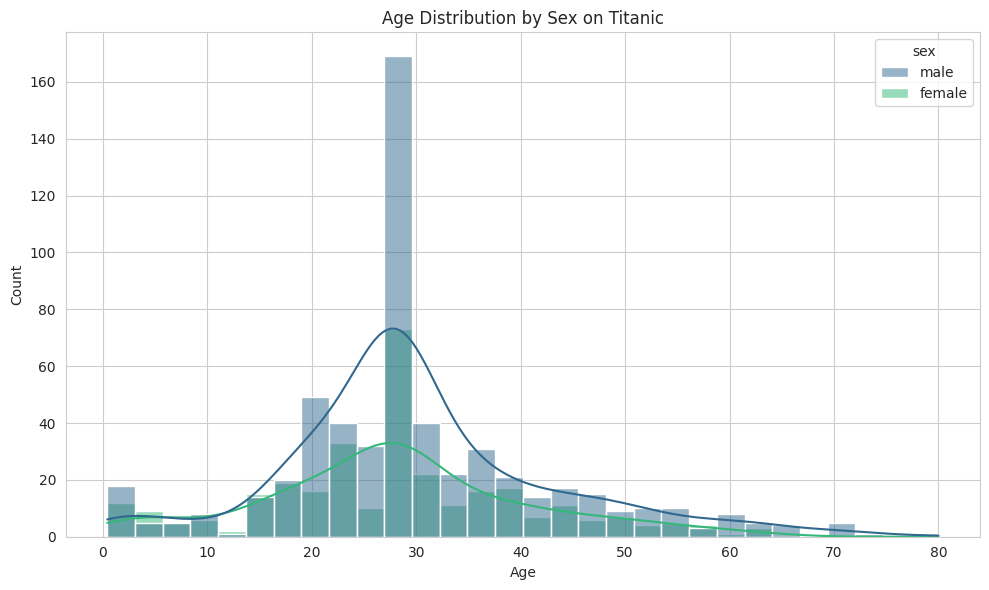

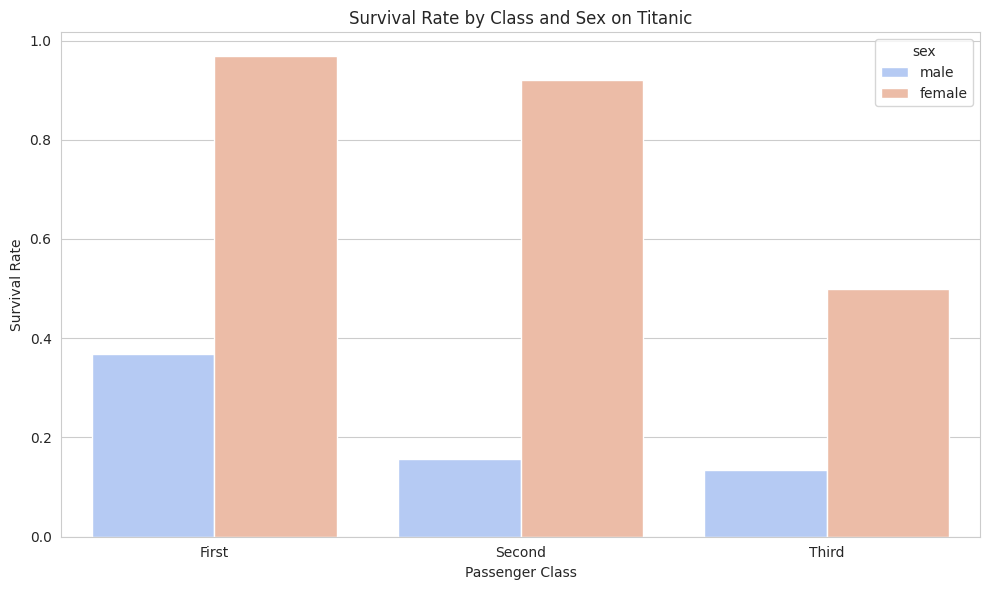

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
sns.set_style("whitegrid")

# Plot 1: Histplot for 'age' with kde=True and hue='sex'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', kde=True, hue='sex', palette='viridis')
plt.title('Age Distribution by Sex on Titanic')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Plot 2: Barplot with 'class' on the x-axis, 'survived' on the y-axis, and hue='sex'
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='class', y='survived', hue='sex', palette='coolwarm', errorbar=None)
plt.title('Survival Rate by Class and Sex on Titanic')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

In [37]:
# Create 'family_size' column by adding 'sibsp' and 'parch'
df['family_size'] = df['sibsp'] + df['parch']
print("DataFrame after creating 'family_size' column:")
display(df.head())

# One-Hot Encode the 'sex' column
df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=int)
print("\nDataFrame after One-Hot Encoding 'sex' column:")
display(df.head())

# Display updated DataFrame info to confirm changes
print('\nUpdated Dataset Info:')
df.info()

DataFrame after creating 'family_size' column:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,0



DataFrame after One-Hot Encoding 'sex' column:


,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,sex_male
0,0,3,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,1,1
1,1,1,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,1,0
2,1,3,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0,0
3,1,1,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,1,0
4,0,3,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,0,1



Updated Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   age          891 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  embark_town  889 non-null    object  
 11  alive        891 non-null    object  
 12  alone        891 non-null    bool    
 13  family_size  891 non-null    int64   
 14  sex_male     891 non-null    int64   
dtypes: bool(2), category(1), float64(2), int64(6), object(4)
memory usage: 86.4+ KB


In [38]:
# Calculate the number of rows where 'adult_male' and 'sex_male' are different
diff_rows = df[df['adult_male'] != df['sex_male']]
num_diff = len(diff_rows)

print(f'Number of rows where adult_male and sex_male differ: {num_diff}')

if num_diff > 0:
    print('\nFirst 5 rows with differences:')
    display(diff_rows[['sex_male', 'adult_male', 'who', 'age']].head())
else:
    print('\nThe columns are identical.')

Number of rows where adult_male and sex_male differ: 40

First 5 rows with differences:


,sex_male,adult_male,who,age
7,1,False,child,2.0
16,1,False,child,2.0
50,1,False,child,7.0
59,1,False,child,11.0
63,1,False,child,4.0


In [39]:
# Drop the 'adult_male' column
df.drop(columns=['adult_male'], inplace=True)

# Create the 'child' column: 1 if 'who' is 'child', else 0
df['child'] = df['who'].apply(lambda x: 1 if x == 'child' else 0)

# Drop the original 'who' column as it's been replaced by 'child'
df.drop(columns=['who'], inplace=True)

print("DataFrame after dropping 'adult_male' and creating 'child' column:")
display(df.head())

# Verify the unique values in the new 'child' column
print("\nValue counts for the new 'child' column:")
print(df['child'].value_counts())

DataFrame after dropping 'adult_male' and creating 'child' column:


,survived,pclass,age,sibsp,parch,fare,embarked,class,embark_town,alive,alone,family_size,sex_male,child
0,0,3,22.0,1,0,7.2500,S,Third,Southampton,no,False,1,1,0
1,1,1,38.0,1,0,71.2833,C,First,Cherbourg,yes,False,1,0,0
2,1,3,26.0,0,0,7.9250,S,Third,Southampton,yes,True,0,0,0
3,1,1,35.0,1,0,53.1000,S,First,Southampton,yes,False,1,0,0
4,0,3,35.0,0,0,8.0500,S,Third,Southampton,no,True,0,1,0



Value counts for the new 'child' column:
child
0    808
1     83
Name: count, dtype: int64


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   age          891 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   embark_town  889 non-null    object  
 9   alive        891 non-null    object  
 10  alone        891 non-null    bool    
 11  family_size  891 non-null    int64   
 12  sex_male     891 non-null    int64   
 13  child        891 non-null    int64   
dtypes: bool(1), category(1), float64(2), int64(7), object(3)
memory usage: 85.5+ KB


In [41]:
df = df.drop(columns=['embark_town', 'fare', 'embarked', 'alive'])

Final dataset ready for an ML Algorithm:


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   age          891 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   class        891 non-null    category
 6   alone        891 non-null    bool    
 7   family_size  891 non-null    int64   
 8   sex_male     891 non-null    int64   
 9   child        891 non-null    int64   
dtypes: bool(1), category(1), float64(1), int64(7)
memory usage: 57.7 KB


In [44]:
df.to_csv("titanic.csv", index=False)